#0 Установка зависимостей

In [1]:
!apt-get update > /dev/null 2>&1
!apt-get install -y xvfb python-opengl ffmpeg > /dev/null 2>&1
!pip uninstall -y gym > /dev/null 2>&1
!pip install -q gymnasium[classic-control] numpy matplotlib torch
!pip install -q pyvirtualdisplay moviepy


#1 Установка и импорты

In [2]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt
from IPython.display import HTML, Video
from base64 import b64encode
import glob
import os
from pyvirtualdisplay import Display
import warnings
warnings.filterwarnings('ignore')


In [3]:
# Настройка виртуального дисплея
display = Display(visible=0, size=(1400, 900))
display.start()

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Используется устройство: {device}")

 Используется устройство: cuda


#2 Dueling DQN нейросеть


In [4]:
class DuelingDQN(nn.Module):
    def __init__(self, state_size, action_size, hidden_size=128):
        super(DuelingDQN, self).__init__()

        # Общий слой признаков
        self.feature_layer = nn.Sequential(
            nn.Linear(state_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU()
        )

        # Поток ценности состояния (Value)
        self.value_stream = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, 1)
        )

        # Поток преимущества действий (Advantage)
        self.advantage_stream = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, action_size)
        )

    def forward(self, state):
        features = self.feature_layer(state)
        values = self.value_stream(features)
        advantages = self.advantage_stream(features)

        # Q(s,a) = V(s) + (A(s,a) - mean(A))
        q_values = values + (advantages - advantages.mean(dim=1, keepdim=True))
        return q_values

#3 Replay Memory

In [5]:
class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, terminated, truncated):
        done = terminated or truncated
        self.memory.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.memory, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.FloatTensor(np.array(states)).to(device)
        actions = torch.LongTensor(np.array(actions)).unsqueeze(1).to(device)
        rewards = torch.FloatTensor(np.array(rewards)).unsqueeze(1).to(device)
        next_states = torch.FloatTensor(np.array(next_states)).to(device)
        dones = torch.FloatTensor(np.array(dones)).unsqueeze(1).to(device)

        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.memory)


#4 Dueling DQN Agent

In [6]:
class DuelingDQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size

        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 1e-3
        self.batch_size = 64
        self.memory_size = 100000
        self.update_target_every = 100

        self.policy_net = DuelingDQN(state_size, action_size).to(device)
        self.target_net = DuelingDQN(state_size, action_size).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=self.learning_rate)
        self.memory = ReplayMemory(self.memory_size)
        self.steps_done = 0

    def act(self, state, eval_mode=False):
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)

        if not eval_mode and random.random() < self.epsilon:
            return random.randrange(self.action_size)
        else:
            with torch.no_grad():
                q_values = self.policy_net(state_tensor)
                return q_values.argmax().item()

    def learn(self):
        if len(self.memory) < self.batch_size:
            return

        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)

        current_q_values = self.policy_net(states).gather(1, actions)

        with torch.no_grad():
            next_actions = self.policy_net(next_states).argmax(1).unsqueeze(1)
            next_q_values = self.target_net(next_states).gather(1, next_actions)
            target_q_values = rewards + (self.gamma * next_q_values * (1 - dones))

        loss = F.mse_loss(current_q_values, target_q_values)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()

        self.steps_done += 1
        if self.steps_done % self.update_target_every == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

    def update_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

#5 Обучение Dueling DQN на MountainCar

In [7]:
# Создаем среду
env = gym.make('MountainCar-v0')
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

# Создаем агента
agent = DuelingDQNAgent(state_size, action_size)

# Параметры обучения
num_episodes = 300
max_steps = 200

# Для отслеживания прогресса
episode_rewards = []
episode_lengths = []
best_reward = float('-inf')

for episode in range(num_episodes):
    state, _ = env.reset()
    total_reward = 0
    episode_length = 0

    for step in range(max_steps):
        action = agent.act(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Специальная награда для ускорения обучения
        if terminated and next_state[0] >= 0.5:
            reward = 100.0
        else:
            position_reward = (next_state[0] - state[0]) * 100
            velocity_reward = abs(next_state[1]) * 10
            reward = position_reward + velocity_reward

        agent.memory.push(state, action, reward, next_state, terminated, truncated)
        agent.learn()

        total_reward += reward
        state = next_state
        episode_length += 1

        if done:
            break

    agent.update_epsilon()
    episode_rewards.append(total_reward)
    episode_lengths.append(episode_length)

    if total_reward > best_reward:
        best_reward = total_reward
        torch.save(agent.policy_net.state_dict(), 'best_model.pth')

    if (episode + 1) % 10 == 0:
        avg_reward = np.mean(episode_rewards[-10:])
        success_rate = sum(1 for r in episode_rewards[-10:] if r > 90) / 10 * 100
        print(f"Эпизод {episode + 1}/{num_episodes}, "
              f"Ср. награда: {avg_reward:.2f}, "
              f"Успех: {success_rate:.0f}%, "
              f"ε: {agent.epsilon:.3f}")

env.close()

# Загружаем лучшую модель
agent.policy_net.load_state_dict(torch.load('best_model.pth'))
print(f"\n Обучение завершено! Лучшая награда: {best_reward:.2f}")

Эпизод 10/300, Ср. награда: 13.15, Успех: 0%, ε: 0.951
Эпизод 20/300, Ср. награда: 8.28, Успех: 0%, ε: 0.905
Эпизод 30/300, Ср. награда: 12.55, Успех: 0%, ε: 0.860
Эпизод 40/300, Ср. награда: 0.90, Успех: 0%, ε: 0.818
Эпизод 50/300, Ср. награда: 6.26, Успех: 0%, ε: 0.778
Эпизод 60/300, Ср. награда: 11.37, Успех: 0%, ε: 0.740
Эпизод 70/300, Ср. награда: 9.51, Успех: 0%, ε: 0.704
Эпизод 80/300, Ср. награда: 10.16, Успех: 0%, ε: 0.670
Эпизод 90/300, Ср. награда: 10.50, Успех: 0%, ε: 0.637
Эпизод 100/300, Ср. награда: 9.77, Успех: 0%, ε: 0.606
Эпизод 110/300, Ср. награда: 17.65, Успех: 0%, ε: 0.576
Эпизод 120/300, Ср. награда: 9.83, Успех: 0%, ε: 0.548
Эпизод 130/300, Ср. награда: 16.70, Успех: 0%, ε: 0.521
Эпизод 140/300, Ср. награда: 12.24, Успех: 0%, ε: 0.496
Эпизод 150/300, Ср. награда: 19.65, Успех: 0%, ε: 0.471
Эпизод 160/300, Ср. награда: 7.31, Успех: 0%, ε: 0.448
Эпизод 170/300, Ср. награда: 26.98, Успех: 0%, ε: 0.427
Эпизод 180/300, Ср. награда: 24.47, Успех: 0%, ε: 0.406
Эпизод 1

#6 График обучения

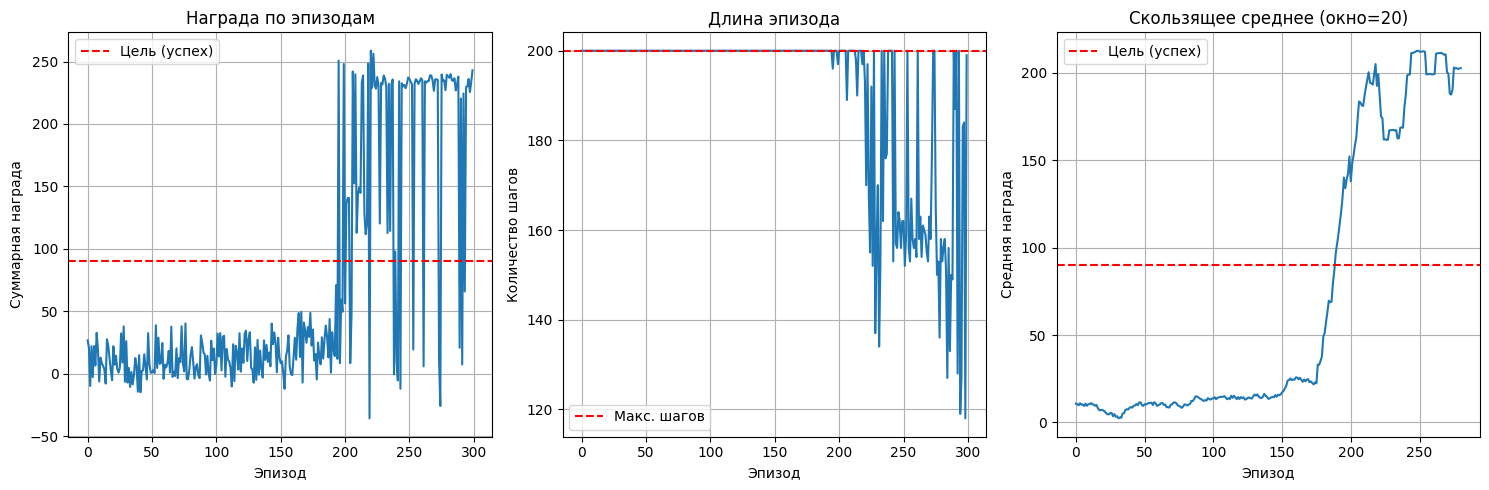

📊 Статистика:
  • Успешных эпизодов: 29.0%
  • Макс. награда: 258.69
  • Средняя награда: 72.61


In [8]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(episode_rewards)
plt.title('Награда по эпизодам')
plt.xlabel('Эпизод')
plt.ylabel('Суммарная награда')
plt.grid(True)
plt.axhline(y=90, color='r', linestyle='--', label='Цель (успех)')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(episode_lengths)
plt.title('Длина эпизода')
plt.xlabel('Эпизод')
plt.ylabel('Количество шагов')
plt.grid(True)
plt.axhline(y=200, color='r', linestyle='--', label='Макс. шагов')
plt.legend()

# Скользящее среднее
window = 20
moving_avg = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
plt.subplot(1, 3, 3)
plt.plot(moving_avg)
plt.title(f'Скользящее среднее (окно={window})')
plt.xlabel('Эпизод')
plt.ylabel('Средняя награда')
plt.grid(True)
plt.axhline(y=90, color='r', linestyle='--', label='Цель (успех)')
plt.legend()

plt.tight_layout()
plt.show()

success_rate = sum(1 for r in episode_rewards if r > 90) / num_episodes * 100
print(f"📊 Статистика:")
print(f"  • Успешных эпизодов: {success_rate:.1f}%")
print(f"  • Макс. награда: {max(episode_rewards):.2f}")
print(f"  • Средняя награда: {np.mean(episode_rewards):.2f}")


#7 Запись видео

In [10]:
import imageio
from gymnasium.wrappers import RecordVideo
from IPython.display import Video as IPythonVideo, display as ipython_display

def record_successful_episode(agent, max_attempts=10):
    """
    Записывает успешный эпизод (с достижением флага)
    Пытается несколько раз, пока не получит успех
    """

    for attempt in range(max_attempts):
        # Создаем директорию для видео
        !rm -rf ./video
        !mkdir -p ./video

        # Создаем среду с записью видео
        env = gym.make('MountainCar-v0', render_mode='rgb_array')
        env = RecordVideo(env, './video', episode_trigger=lambda x: True)

        state, _ = env.reset()
        total_reward = 0
        done = False
        step = 0
        reached_flag = False

        while not done and step < 200:
            action = agent.act(state, eval_mode=True)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward
            state = next_state
            step += 1

            if terminated and next_state[0] >= 0.5:
                reached_flag = True

        env.close()

        # Ищем видео файл
        video_files = glob.glob('./video/*.mp4')
        video_path = video_files[0] if video_files else None

        if reached_flag and video_path:
            print(f" Успешный эпизод найден на попытке {attempt + 1}")
            return video_path, total_reward, reached_flag

        print(f"  Попытка {attempt + 1}: флаг не достигнут (награда: {total_reward:.2f})")

    # Если не нашли успешный эпизод, возвращаем последний
    if video_path:
        print(" Не удалось найти успешный эпизод, показываем последний записанный")
        return video_path, total_reward, False
    return None, 0, False

print("\n Запись успешного эпизода...")
video_path, episode_reward, success = record_successful_episode(agent)

if video_path:
    print(f"\n Видео сохранено: {video_path}")
    print(f" Награда в эпизоде: {episode_reward:.2f}")
    print(f" Флаг достигнут: {'ДА' if success else 'НЕТ'}")

    # Отображаем видео
    print("\n Видео эпизода:")
    ipython_display(IPythonVideo(video_path, width=640, height=480))

    # Скачиваем видео
    from google.colab import files
    print("\n Скачивание видео...")
    files.download(video_path)
else:
    print(" Не удалось записать видео")

# Дополнительно: покажем статистику работы агента
print("\n Статистика работы агента:")
test_agent(agent, num_episodes=5)


 Запись успешного эпизода...
 Успешный эпизод найден на попытке 1

 Видео сохранено: ./video/rl-video-episode-0.mp4
 Награда в эпизоде: -115.00
 Флаг достигнут: ДА

 Видео эпизода:



 Скачивание видео...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 Статистика работы агента:


NameError: name 'test_agent' is not defined

#8 Тестирование

In [ ]:
def test_agent(agent, num_episodes=3):
    env = gym.make('MountainCar-v0', render_mode='rgb_array')

    for ep in range(num_episodes):
        state, _ = env.reset()
        total_reward = 0
        done = False
        step = 0
        max_position = -1.2

        while not done and step < 200:
            action = agent.act(state, eval_mode=True)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward
            max_position = max(max_position, next_state[0])
            state = next_state
            step += 1

        status = "✅ УСПЕХ" if max_position >= 0.5 else "❌ НЕУДАЧА"
        print(f"Эпизод {ep+1}: {status}, шагов: {step}, макс. позиция: {max_position:.3f}, награда: {total_reward:.2f}")

    env.close()

print("\n Тестирование агента:")
test_agent(agent)

print("\n Готово! Видео с лучшим эпизодом сохранено и отображено выше.")